segregating   D_v=0.010  nruns=2  <rho_A>=0.34891  <rho_B>=0.35086  amp=6.0392  SAA exponent=-3.765
integrating   D_v=0.010  nruns=2  <rho_A>=0.36252  <rho_B>=0.33695  amp=6.5394  SAA exponent=-3.721
migrating     D_v=0.010  nruns=2  <rho_A>=0.34124  <rho_B>=0.35897  amp=6.9352  SAA exponent=-3.753
well-mixed    D_v=0.010  nruns=2  <rho_A>=0.35135  <rho_B>=0.34888  amp=6.4463  SAA exponent=-3.734
segregating   D_v=0.200  nruns=2  <rho_A>=0.34344  <rho_B>=0.35633  amp=2.5982  SAA exponent=-3.488
integrating   D_v=0.200  nruns=2  <rho_A>=0.34526  <rho_B>=0.35421  amp=3.1998  SAA exponent=-3.429
migrating     D_v=0.200  nruns=2  <rho_A>=0.33789  <rho_B>=0.36231  amp=2.6572  SAA exponent=-3.376
well-mixed    D_v=0.200  nruns=2  <rho_A>=0.32343  <rho_B>=0.37680  amp=3.0316  SAA exponent=-3.425


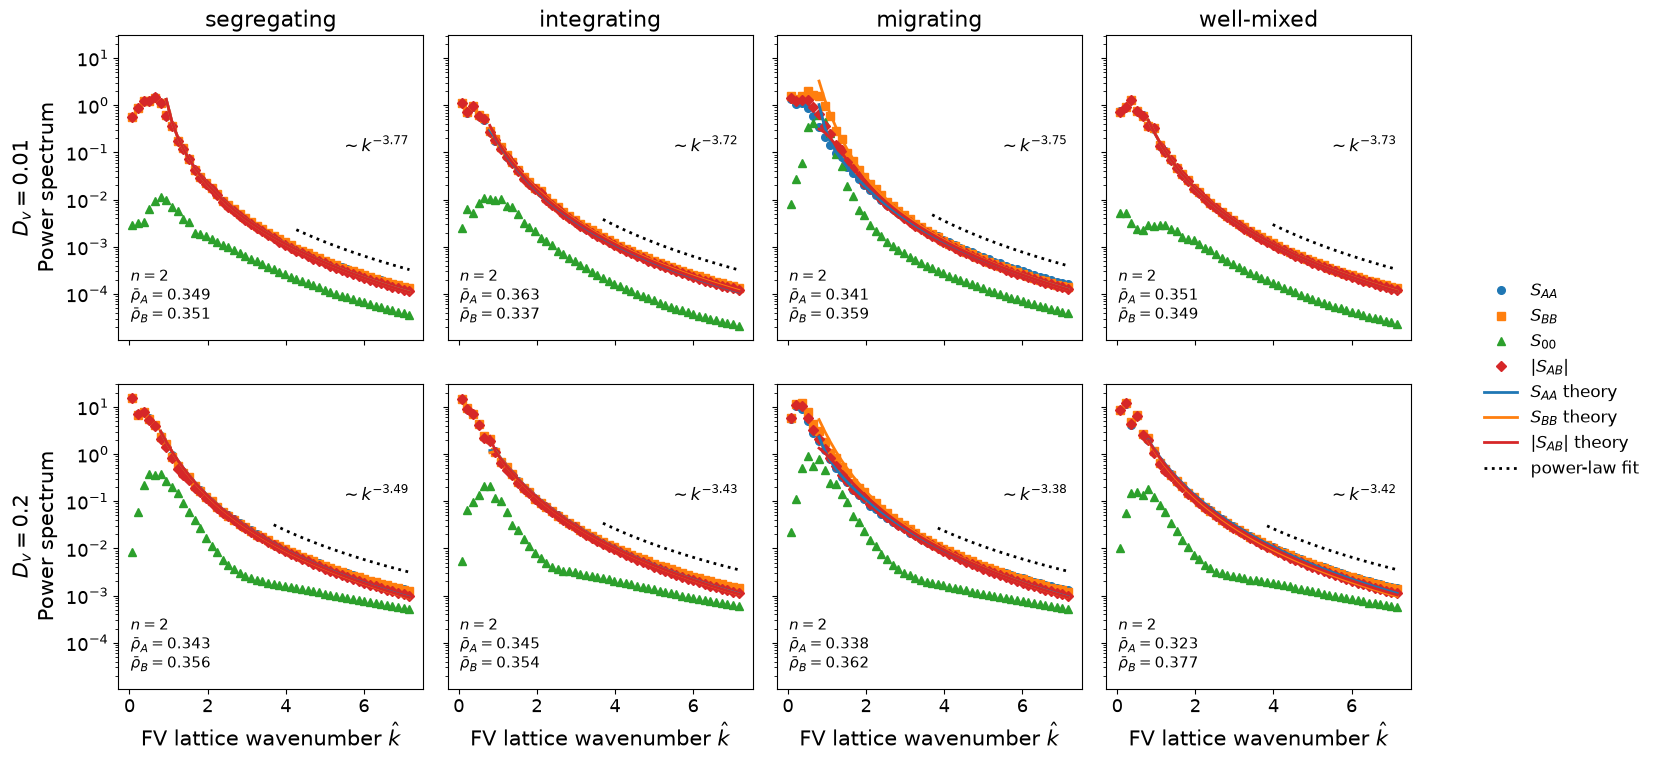

In [15]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt

from fhd.structure_factor import structure_factor


# =============================================================================
# Configuration
# =============================================================================

# For the local smoke test:
DATA_ROOT = Path("data")

# For the eventual full cluster output, change to:
# DATA_ROOT = Path("data")

REGIMES = (
    "segregating",
    "integrating",
    "migrating",
    "well-mixed",
)

DV_VALUES_TO_PLOT = (0.01, 0.20)

TAIL_FRAMES = 200

# Set to 1 for the local test.
# Change to 10 for the full production data if you want the script
# to explicitly require all 10 realizations.
EXPECTED_NRUNS = 2

# Optional upper cutoff in lattice k.
K_MAX_CUTOFF = None

# Number of low-k theory points to omit from display / amplitude fit.
THEORY_SKIP = 5


# =============================================================================
# Styling
# =============================================================================

title_fs = 16
label_fs = 15
tick_fs = 13
legend_fs = 12
text_fs = 12

lw_th = 2.0
lw_ref = 2.0
ms = 5.5

plt.rcParams.update({
    "font.size": tick_fs,
    "axes.labelsize": label_fs,
    "axes.titlesize": title_fs,
    "xtick.labelsize": tick_fs,
    "ytick.labelsize": tick_fs,
    "legend.fontsize": legend_fs,
})


# =============================================================================
# Helpers
# =============================================================================

def fit_amplitude_logspace(theory, data):
    """
    Fit one multiplicative amplitude:

        data ~= amp * theory

    by minimizing the difference in log space.
    """
    theory = np.asarray(theory)
    data = np.asarray(data)

    valid = (
        np.isfinite(theory)
        & np.isfinite(data)
        & (theory > 0)
        & (data > 0)
    )

    if not np.any(valid):
        return 1.0

    return np.exp(
        np.mean(
            np.log(data[valid])
            - np.log(theory[valid])
        )
    )


def get_k_mask(k_bins, k_max_cutoff=None):
    mask = np.isfinite(k_bins) & (k_bins > 0)

    if k_max_cutoff is not None:
        mask &= k_bins <= k_max_cutoff

    return mask


def get_dynamic_fit_mask(
    k_bins,
    k_mask,
    power_spectra,
    G_AB,
    n_after_peak=2,
):
    """
    Start the normalization fit a few points after the largest feature
    in the empirical AA, BB, or |AB| spectra.
    """
    envelope = np.nanmax(
        np.vstack([
            np.where(k_mask, power_spectra[0], np.nan),
            np.where(k_mask, power_spectra[1], np.nan),
            np.where(k_mask, np.abs(G_AB), np.nan),
        ]),
        axis=0,
    )

    if np.all(np.isnan(envelope)):
        idx_start = 1
    else:
        idx_start = np.nanargmax(envelope) + n_after_peak

    idx = np.arange(len(k_bins))
    fit_mask = k_mask & (idx >= idx_start)

    if np.sum(fit_mask) < 3:
        fit_mask = k_mask & (
            idx >= max(1, idx_start - n_after_peak)
        )

    return fit_mask


def fit_power_law_tail(
    k,
    y,
    n_after_peak=5,
    min_points=4,
):
    """
    Fit y ~ A k^alpha to the high-k tail.
    """
    valid = (
        np.isfinite(k)
        & np.isfinite(y)
        & (k > 0)
        & (y > 0)
    )

    k_valid = k[valid]
    y_valid = y[valid]

    if len(k_valid) < min_points:
        return np.nan, np.nan, np.zeros_like(k, dtype=bool)

    peak_idx = np.argmax(y_valid)
    start_idx = peak_idx + n_after_peak

    if start_idx >= len(k_valid) - min_points:
        start_idx = max(0, len(k_valid) - min_points)

    k_tail = k_valid[start_idx:]
    y_tail = y_valid[start_idx:]

    if len(k_tail) < 2:
        return np.nan, np.nan, np.zeros_like(k, dtype=bool)

    alpha, logA = np.polyfit(
        np.log(k_tail),
        np.log(y_tail),
        1,
    )

    A = np.exp(logA)

    tail_mask = np.zeros_like(k, dtype=bool)
    valid_indices = np.where(valid)[0]
    tail_mask[valid_indices[start_idx:]] = True

    return alpha, A, tail_mask


def add_fitted_powerlaw_reference(
    ax,
    k,
    y,
    exponent,
    tail_mask,
    vertical_shift=2.5,
    label=None,
):
    if not np.isfinite(exponent):
        return

    if np.sum(tail_mask) < 2:
        return

    k_tail = k[tail_mask]
    y_tail = y[tail_mask]

    valid = (
        np.isfinite(k_tail)
        & np.isfinite(y_tail)
        & (k_tail > 0)
        & (y_tail > 0)
    )

    k_tail = k_tail[valid]
    y_tail = y_tail[valid]

    if len(k_tail) < 2:
        return

    k0 = k_tail[0]
    y0 = vertical_shift * y_tail[0]

    y_ref = y0 * (k_tail / k0) ** exponent

    ax.plot(
        k_tail,
        y_ref,
        "k:",
        lw=lw_ref,
        label=label,
    )


# =============================================================================
# NPZ loading
# =============================================================================

RUN_RE = re.compile(r"VS_run_(\d+)_Dv(\d+)_.*\.npz$")


def find_runs(regime, target_Dv):
    """
    Find all NPZ files for a regime whose stored D_v matches target_Dv.

    We select by the D_v stored inside the file rather than by Dv index.
    This means the same plotting script works for:

        local test: DV_VALS = [0.01, 0.20]
        full sweep: DV_VALS = linspace(0.01, 0.20, 20)
    """
    regime_dir = DATA_ROOT / regime

    if not regime_dir.exists():
        raise FileNotFoundError(
            f"Missing regime directory: {regime_dir}"
        )

    matches = []

    for path in sorted(regime_dir.glob("VS_run_*_Dv*_*.npz")):
        with np.load(path, allow_pickle=False) as z:
            Dv_file = float(z["D_v"])

        if np.isclose(
            Dv_file,
            target_Dv,
            rtol=0.0,
            atol=1e-12,
        ):
            matches.append(path)

    if not matches:
        raise FileNotFoundError(
            f"No files found for regime={regime}, D_v={target_Dv}"
        )

    # Check that each run appears only once.
    run_indices = []

    for path in matches:
        match = RUN_RE.match(path.name)
        if match is None:
            raise RuntimeError(
                f"Could not parse run index from {path.name}"
            )

        run_indices.append(int(match.group(1)))

    if len(run_indices) != len(set(run_indices)):
        raise RuntimeError(
            f"Duplicate run indices for {regime}, D_v={target_Dv}: "
            f"{run_indices}"
        )

    if EXPECTED_NRUNS is not None:
        if len(matches) != EXPECTED_NRUNS:
            raise RuntimeError(
                f"{regime}, D_v={target_Dv}: expected "
                f"{EXPECTED_NRUNS} runs, found {len(matches)}"
            )

    return matches


def load_ensemble_panel(regime, target_Dv):
    """
    Load late-time quantities for all runs of one (regime, D_v) panel.

    Each stored *_tail_mean spectrum has already been averaged over
    the final 200 recorded frames. Here we average those quantities
    over independent runs.
    """
    paths = find_runs(regime, target_Dv)

    spectrum_names = (
        "S_AA",
        "S_BB",
        "S_00",
        "S_AB",
    )

    spectra_runs = {
        name: []
        for name in spectrum_names
    }

    rhoA_runs = []
    rhoB_runs = []

    params = None
    k_bins = None

    for path in paths:
        with np.load(path, allow_pickle=False) as z:

            # ---------------------------------------------------------
            # Verify tail averaging
            # ---------------------------------------------------------
            tail_n = int(z["tail_nframes"])

            if tail_n != TAIL_FRAMES:
                raise RuntimeError(
                    f"{path.name}: expected tail_nframes="
                    f"{TAIL_FRAMES}, found {tail_n}"
                )

            tail_idx = z["tail_frame_indices"]

            # ---------------------------------------------------------
            # k grid
            # ---------------------------------------------------------
            k_this = z["k_centers"]

            if k_bins is None:
                k_bins = k_this.copy()
            elif not np.allclose(
                k_bins,
                k_this,
                rtol=1e-12,
                atol=1e-14,
                equal_nan=True,
            ):
                raise RuntimeError(
                    f"k grid differs in {path}"
                )

            # ---------------------------------------------------------
            # Already time-averaged final-200-frame spectra
            # ---------------------------------------------------------
            for name in spectrum_names:
                spectra_runs[name].append(
                    z[f"{name}_tail_mean"].copy()
                )

            # ---------------------------------------------------------
            # Late-time background density for theory
            # ---------------------------------------------------------
            rhoA_runs.append(
                float(
                    np.mean(
                        z["mean_A"][tail_idx]
                    )
                )
            )

            rhoB_runs.append(
                float(
                    np.mean(
                        z["mean_B"][tail_idx]
                    )
                )
            )

            # ---------------------------------------------------------
            # Simulation parameters: read them from the file!
            # ---------------------------------------------------------
            p_this = {
                "h": float(z["h"]),
                "D": z["D"].copy(),
                "Gamma": z["Gamma"].copy(),
                "beta": float(z["beta"]),
                "kappa": z["kappa"].copy(),
                "D_v": float(z["D_v"]),
            }

            if params is None:
                params = p_this
            else:
                if not np.allclose(params["D"], p_this["D"]):
                    raise RuntimeError("D differs across runs")
                if not np.allclose(params["Gamma"], p_this["Gamma"]):
                    raise RuntimeError("Gamma differs across runs")
                if not np.allclose(params["kappa"], p_this["kappa"]):
                    raise RuntimeError("kappa differs across runs")
                if not np.isclose(params["beta"], p_this["beta"]):
                    raise RuntimeError("beta differs across runs")
                if not np.isclose(params["h"], p_this["h"]):
                    raise RuntimeError("h differs across runs")
                if not np.isclose(params["D_v"], p_this["D_v"]):
                    raise RuntimeError("D_v differs across runs")

    # Stack into (nruns, nk)
    for name in spectrum_names:
        spectra_runs[name] = np.asarray(
            spectra_runs[name]
        )

    rhoA_runs = np.asarray(rhoA_runs)
    rhoB_runs = np.asarray(rhoB_runs)

    # Ensemble average after the per-run time average.
    spectra_mean = {
        name: np.nanmean(values, axis=0)
        for name, values in spectra_runs.items()
    }

    # Useful if you later want error bars / bands.
    spectra_std = {
        name: (
            np.nanstd(values, axis=0, ddof=1)
            if len(paths) > 1
            else np.full(values.shape[1], np.nan)
        )
        for name, values in spectra_runs.items()
    }

    return {
        "paths": paths,
        "nruns": len(paths),
        "k": k_bins,
        "spectra_runs": spectra_runs,
        "spectra_mean": spectra_mean,
        "spectra_std": spectra_std,
        "rhoA_runs": rhoA_runs,
        "rhoB_runs": rhoB_runs,
        "rhoA_mean": np.mean(rhoA_runs),
        "rhoB_mean": np.mean(rhoB_runs),
        "params": params,
    }


# =============================================================================
# Theory
# =============================================================================

def ensemble_theory(panel):
    """
    Compute theory separately using the late-time mean density of each
    simulation, then average the resulting theory over runs.

    This is slightly preferable to first averaging rho_A and rho_B because
    structure_factor() is not necessarily linear in the background density.
    """
    k_bins = panel["k"]
    params = panel["params"]

    nruns = panel["nruns"]
    nk = len(k_bins)

    S_AA_runs = np.empty((nruns, nk), dtype=complex)
    S_AB_runs = np.empty((nruns, nk), dtype=complex)
    S_BB_runs = np.empty((nruns, nk), dtype=complex)

    for r, (rhoA, rhoB) in enumerate(
        zip(
            panel["rhoA_runs"],
            panel["rhoB_runs"],
        )
    ):
        for i, k in enumerate(k_bins):
            S = structure_factor(
                k,
                rhoA,
                rhoB,
                params,
            )

            S_AA_runs[r, i] = S[0, 0]
            S_AB_runs[r, i] = S[0, 1]
            S_BB_runs[r, i] = S[1, 1]

    return {
        "S_AA": np.mean(S_AA_runs, axis=0),
        "S_AB": np.mean(S_AB_runs, axis=0),
        "S_BB": np.mean(S_BB_runs, axis=0),
    }


# =============================================================================
# Figure
# =============================================================================

fig, axes = plt.subplots(
    nrows=len(DV_VALUES_TO_PLOT),
    ncols=len(REGIMES),
    figsize=(16, 8),
    sharex=True,
    sharey=True,
)

# Makes axes indexing robust if only one D_v is requested.
axes = np.atleast_2d(axes)


for row_idx, Dv in enumerate(DV_VALUES_TO_PLOT):

    for regime_idx, regime in enumerate(REGIMES):

        ax = axes[row_idx, regime_idx]

        # -------------------------------------------------------------
        # Load empirical ensemble
        # -------------------------------------------------------------
        panel = load_ensemble_panel(
            regime,
            Dv,
        )

        k_bins = panel["k"]

        S_AA_data = panel["spectra_mean"]["S_AA"]
        S_BB_data = panel["spectra_mean"]["S_BB"]
        S_00_data = panel["spectra_mean"]["S_00"]
        S_AB_data = panel["spectra_mean"]["S_AB"]

        power_spectra = np.vstack([
            S_AA_data,
            S_BB_data,
            S_00_data,
        ])

        # -------------------------------------------------------------
        # Theory, also averaged over runs
        # -------------------------------------------------------------
        theory = ensemble_theory(panel)

        S_AA_theory = theory["S_AA"]
        S_AB_theory = theory["S_AB"]
        S_BB_theory = theory["S_BB"]

        # -------------------------------------------------------------
        # Masks
        # -------------------------------------------------------------
        k_mask = get_k_mask(
            k_bins,
            k_max_cutoff=K_MAX_CUTOFF,
        )

        fit_mask = get_dynamic_fit_mask(
            k_bins,
            k_mask,
            power_spectra,
            S_AB_data,
            n_after_peak=2,
        )

        theory_indices_all = np.where(k_mask)[0]

        if len(theory_indices_all) > THEORY_SKIP:
            fit_mask[
                theory_indices_all[:THEORY_SKIP]
            ] = False

        # -------------------------------------------------------------
        # One common amplitude normalization for AA, BB and |AB|
        # -------------------------------------------------------------
        theory_fit = np.vstack([
            S_AA_theory[fit_mask].real,
            S_BB_theory[fit_mask].real,
            np.abs(S_AB_theory[fit_mask]),
        ])

        data_fit = np.vstack([
            S_AA_data[fit_mask],
            S_BB_data[fit_mask],
            np.abs(S_AB_data[fit_mask]),
        ])

        amp = fit_amplitude_logspace(
            theory_fit,
            data_fit,
        )

        # -------------------------------------------------------------
        # Display masks
        # -------------------------------------------------------------
        plot_mask = k_mask

        k_plot = k_bins[plot_mask]

        theory_indices = np.where(plot_mask)[0]
        theory_plot_indices = theory_indices[
            THEORY_SKIP:
        ]

        # -------------------------------------------------------------
        # Data
        # -------------------------------------------------------------
        ax.plot(
            k_plot,
            S_AA_data[plot_mask],
            linestyle="None",
            marker="o",
            color="tab:blue",
            ms=ms,
            label=r"$S_{AA}$",
        )

        ax.plot(
            k_plot,
            S_BB_data[plot_mask],
            linestyle="None",
            marker="s",
            color="tab:orange",
            ms=ms,
            label=r"$S_{BB}$",
        )

        ax.plot(
            k_plot,
            S_00_data[plot_mask],
            linestyle="None",
            marker="^",
            color="tab:green",
            ms=ms,
            label=r"$S_{00}$",
        )

        ax.plot(
            k_plot,
            np.abs(S_AB_data[plot_mask]),
            linestyle="None",
            marker="D",
            color="tab:red",
            ms=ms,
            label=r"$|S_{AB}|$",
        )

        # -------------------------------------------------------------
        # Theory
        # -------------------------------------------------------------
        k_th = k_bins[theory_plot_indices]

        SAA_th = S_AA_theory[
            theory_plot_indices
        ].real

        SBB_th = S_BB_theory[
            theory_plot_indices
        ].real

        SAB_th = S_AB_theory[
            theory_plot_indices
        ].real

        positive = (
            np.isfinite(SAA_th)
            & (SAA_th > 0)
        )

        ax.plot(
            k_th[positive],
            amp * SAA_th[positive],
            "-",
            color="tab:blue",
            lw=lw_th,
            label=r"$S_{AA}$ theory",
        )

        positive = (
            np.isfinite(SBB_th)
            & (SBB_th > 0)
        )

        ax.plot(
            k_th[positive],
            amp * SBB_th[positive],
            "-",
            color="tab:orange",
            lw=lw_th,
            label=r"$S_{BB}$ theory",
        )

        # Preserve the sign convention from your previous plot:
        # the theoretical AB correlation is negative, and the figure
        # shows its magnitude.
        negative = (
            np.isfinite(SAB_th)
            & (SAB_th < 0)
        )

        ax.plot(
            k_th[negative],
            -amp * SAB_th[negative],
            "-",
            color="tab:red",
            lw=lw_th,
            label=r"$|S_{AB}|$ theory",
        )

        # -------------------------------------------------------------
        # High-k S_AA exponent
        # -------------------------------------------------------------
        SAA_plot = S_AA_data[plot_mask]

        exponent, A_fit, tail_mask = fit_power_law_tail(
            k_plot,
            SAA_plot,
            n_after_peak=25,
            min_points=4,
        )

        add_fitted_powerlaw_reference(
            ax,
            k_plot,
            SAA_plot,
            exponent,
            tail_mask,
            vertical_shift=2.5,
            label=(
                r"power-law fit"
                if row_idx == 0 and regime_idx == 0
                else None
            ),
        )

        if np.isfinite(exponent):
            ax.text(
                0.73,
                0.67,
                fr"$\sim k^{{{exponent:.2f}}}$",
                transform=ax.transAxes,
                fontsize=text_fs,
                va="top",
                ha="left",
            )

        # -------------------------------------------------------------
        # Panel information
        # -------------------------------------------------------------
        ax.text(
            0.04,
            0.05,
            (
                fr"$n={panel['nruns']}$"
                "\n"
                fr"$\bar\rho_A={panel['rhoA_mean']:.3f}$"
                "\n"
                fr"$\bar\rho_B={panel['rhoB_mean']:.3f}$"
            ),
            transform=ax.transAxes,
            fontsize=text_fs - 1,
            va="bottom",
            ha="left",
        )

        # -------------------------------------------------------------
        # Axes
        # -------------------------------------------------------------

        # THIS is the requested change:
        ax.set_xscale("linear")

        # Keep spectrum logarithmic.
        ax.set_yscale("log")

        ax.set_box_aspect(1)

        if row_idx == 0:
            ax.set_title(regime)

        if regime_idx == 0:
            ax.set_ylabel(
                fr"$D_v={Dv:g}$"
                "\nPower spectrum"
            )

        if row_idx == len(DV_VALUES_TO_PLOT) - 1:
            ax.set_xlabel(
                r"FV lattice wavenumber $\hat{k}$"
            )

        ax.tick_params(
            axis="both",
            which="both",
            labelsize=tick_fs,
        )

        print(
            f"{regime:12s}  "
            f"D_v={Dv:.3f}  "
            f"nruns={panel['nruns']}  "
            f"<rho_A>={panel['rhoA_mean']:.5f}  "
            f"<rho_B>={panel['rhoB_mean']:.5f}  "
            f"amp={amp:.5g}  "
            f"SAA exponent={exponent:.3f}"
        )


# =============================================================================
# Global legend
# =============================================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(1.04, 0.5),
    frameon=False,
    fontsize=legend_fs,
)

plt.tight_layout(
    rect=[0, 0, 0.90, 1.0]
)

# plt.savefig(
#     "images/Schelling_Voter_PS_FV.pdf",
#     bbox_inches="tight",
# )

plt.show()

segregating  | D_v=0.010 | nruns=2 | <rho_A>=0.34891 | <rho_B>=0.35086 | amp=6.0392
integrating  | D_v=0.010 | nruns=2 | <rho_A>=0.36252 | <rho_B>=0.33695 | amp=6.5394
migrating    | D_v=0.010 | nruns=2 | <rho_A>=0.34124 | <rho_B>=0.35897 | amp=6.9352
well-mixed   | D_v=0.010 | nruns=2 | <rho_A>=0.35135 | <rho_B>=0.34888 | amp=6.4463
segregating  | D_v=0.200 | nruns=2 | <rho_A>=0.34344 | <rho_B>=0.35633 | amp=2.5982
integrating  | D_v=0.200 | nruns=2 | <rho_A>=0.34526 | <rho_B>=0.35421 | amp=3.1998
migrating    | D_v=0.200 | nruns=2 | <rho_A>=0.33789 | <rho_B>=0.36231 | amp=2.6572
well-mixed   | D_v=0.200 | nruns=2 | <rho_A>=0.32343 | <rho_B>=0.37680 | amp=3.0316


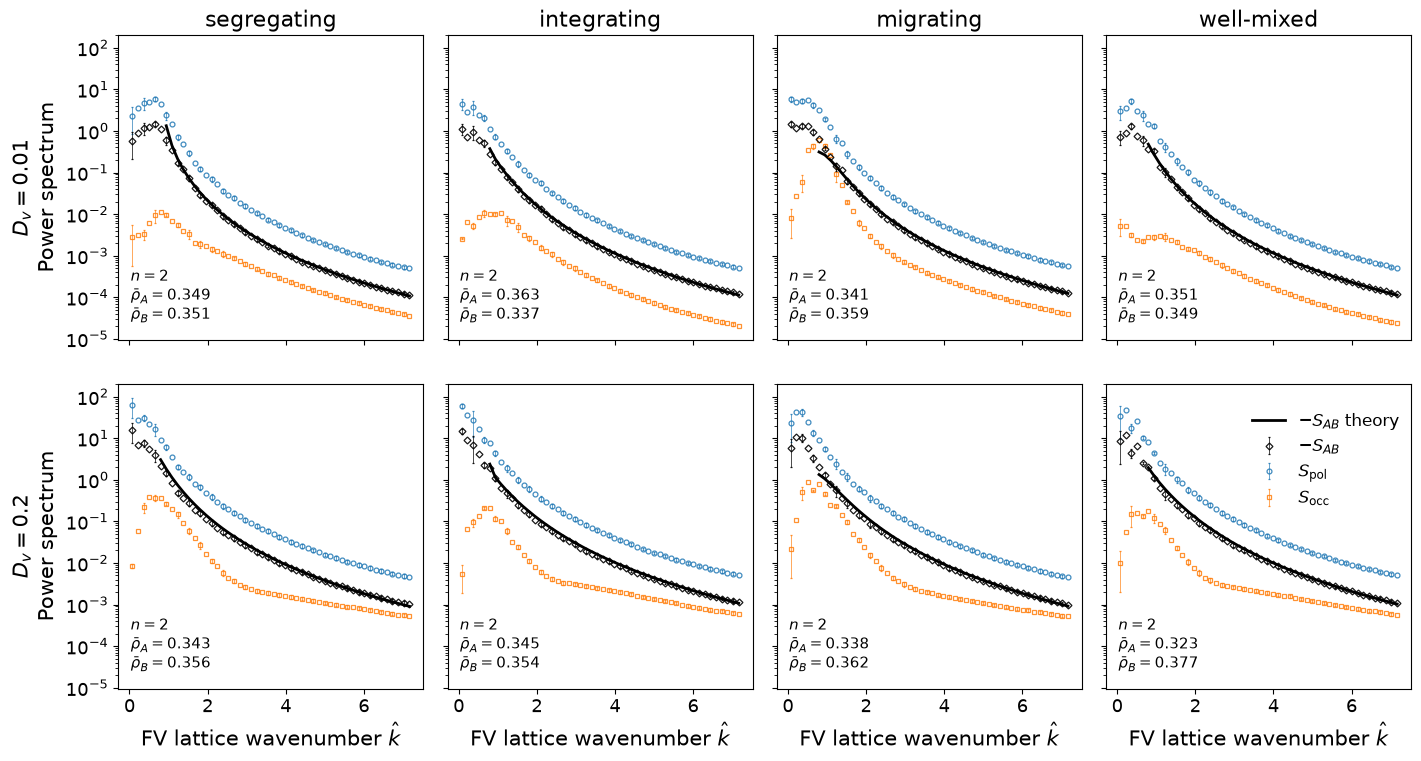

In [ ]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt

from fhd.structure_factor import structure_factor


# =============================================================================
# Configuration
# =============================================================================

# Local test data:
# DATA_ROOT = Path("data_smoke")

# Later, for the full cluster output:
DATA_ROOT = Path("data")

REGIMES = (
    "segregating",
    "integrating",
    "migrating",
    "well-mixed",
)

DV_VALUES_TO_PLOT = (0.01, 0.20)

TAIL_FRAMES = 200

# For your current local test:
EXPECTED_NRUNS = 2

# For the production sweep later:
# EXPECTED_NRUNS = 10


# Optional upper cutoff in lattice k.
# Leave as None to show the full range.
K_MAX_CUTOFF = None

# Number of low-k theory points to omit.
THEORY_SKIP = 5

# Plot error bars only every N radial bins.
# Change to 1 if you want an error bar on every point.
ERROR_EVERY = 2


# =============================================================================
# Plot styling
# =============================================================================

title_fs = 16
label_fs = 15
tick_fs = 13
legend_fs = 12
text_fs = 11

marker_size = 3.5
lw_theory = 2.2

plt.rcParams.update({
    "font.size": tick_fs,
    "axes.labelsize": label_fs,
    "axes.titlesize": title_fs,
    "xtick.labelsize": tick_fs,
    "ytick.labelsize": tick_fs,
    "legend.fontsize": legend_fs,
})


# =============================================================================
# Helper functions
# =============================================================================

def fit_amplitude_logspace(theory, data):
    """
    Fit a single multiplicative amplitude:

        data ~= amp * theory

    in log space.
    """
    theory = np.asarray(theory)
    data = np.asarray(data)

    valid = (
        np.isfinite(theory)
        & np.isfinite(data)
        & (theory > 0)
        & (data > 0)
    )

    if not np.any(valid):
        return 1.0

    log_amp = np.mean(
        np.log(data[valid])
        - np.log(theory[valid])
    )

    return np.exp(log_amp)


def get_k_mask(k_bins, k_max_cutoff=None):
    """
    Select positive finite lattice wavenumbers.
    """
    mask = (
        np.isfinite(k_bins)
        & (k_bins > 0)
    )

    if k_max_cutoff is not None:
        mask &= k_bins <= k_max_cutoff

    return mask


def get_dynamic_fit_mask(
    k_bins,
    k_mask,
    S_AA,
    S_BB,
    S_AB,
    n_after_peak=2,
):
    """
    Start the theory-amplitude fit a few points after the largest
    feature in S_AA, S_BB, or |S_AB|.
    """

    envelope = np.nanmax(
        np.vstack([
            np.where(k_mask, S_AA, np.nan),
            np.where(k_mask, S_BB, np.nan),
            np.where(k_mask, np.abs(S_AB), np.nan),
        ]),
        axis=0,
    )

    if np.all(np.isnan(envelope)):
        idx_start = 1
    else:
        idx_start = (
            np.nanargmax(envelope)
            + n_after_peak
        )

    idx = np.arange(len(k_bins))

    fit_mask = (
        k_mask
        & (idx >= idx_start)
    )

    # Fall back slightly if too few bins remain.
    if np.sum(fit_mask) < 3:
        fit_mask = (
            k_mask
            & (
                idx
                >= max(
                    1,
                    idx_start - n_after_peak,
                )
            )
        )

    return fit_mask


def log_safe_yerr(y, sigma, floor_fraction=0.8):
    """
    Construct asymmetric error bars suitable for a logarithmic y-axis.

    The upper error is unchanged.
    The lower error is capped so the error bar never crosses zero.
    """
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    lower = np.minimum(
        sigma,
        floor_fraction * y,
    )

    upper = sigma

    return np.vstack([
        lower,
        upper,
    ])


# =============================================================================
# Locate NPZ files
# =============================================================================

RUN_RE = re.compile(
    r"VS_run_(\d+)_Dv(\d+)_.*\.npz$"
)


def find_runs(regime, target_Dv):
    """
    Find all runs for one regime and one D_v.

    Selection is based on the D_v stored inside the NPZ rather than
    assuming any particular D_v index.
    """
    regime_dir = DATA_ROOT / regime

    if not regime_dir.exists():
        raise FileNotFoundError(
            f"Missing directory: {regime_dir}"
        )

    matches = []

    for path in sorted(
        regime_dir.glob("VS_run_*_Dv*_*.npz")
    ):
        with np.load(
            path,
            allow_pickle=False,
        ) as z:

            Dv_file = float(z["D_v"])

        if np.isclose(
            Dv_file,
            target_Dv,
            rtol=0.0,
            atol=1e-12,
        ):
            matches.append(path)

    if len(matches) == 0:
        raise FileNotFoundError(
            f"No runs found for "
            f"regime={regime}, D_v={target_Dv}"
        )

    # -------------------------------------------------------------
    # Verify run indices are unique
    # -------------------------------------------------------------
    run_indices = []

    for path in matches:

        match = RUN_RE.match(path.name)

        if match is None:
            raise RuntimeError(
                f"Could not parse filename: "
                f"{path.name}"
            )

        run_indices.append(
            int(match.group(1))
        )

    if len(run_indices) != len(set(run_indices)):
        raise RuntimeError(
            f"Duplicate run indices for "
            f"{regime}, D_v={target_Dv}: "
            f"{run_indices}"
        )

    # -------------------------------------------------------------
    # Optional completeness check
    # -------------------------------------------------------------
    if EXPECTED_NRUNS is not None:

        if len(matches) != EXPECTED_NRUNS:
            raise RuntimeError(
                f"{regime}, D_v={target_Dv}: "
                f"expected {EXPECTED_NRUNS} runs, "
                f"found {len(matches)}"
            )

    return matches


# =============================================================================
# Load one ensemble panel
# =============================================================================

def load_ensemble_panel(regime, target_Dv):
    """
    Load all independent realizations for one (regime, D_v).

    Each NPZ already contains:

        S_*_tail_mean
            mean spectrum over the final TAIL_FRAMES

        S_*_tail_std
            temporal standard deviation over the final TAIL_FRAMES

    We then combine:

        within-run variance
            mean over runs of S_*_tail_std**2

    and:

        between-run variance
            variance across the run-wise tail means

    according to:

        Var_total
            = E_r[Var(S | r)]
            + Var_r[E(S | r)].
    """
    paths = find_runs(
        regime,
        target_Dv,
    )

    spectrum_names = (
        "S_AA",     # retained for theory-amplitude fit
        "S_BB",     # retained for theory-amplitude fit
        "S_AB",
        "S_pol",
        "S_occ",
    )

    run_tail_means = {
        name: []
        for name in spectrum_names
    }

    run_tail_stds = {
        name: []
        for name in spectrum_names
    }

    rhoA_runs = []
    rhoB_runs = []

    k_bins = None
    params = None

    # -----------------------------------------------------------------
    # Read each independent realization
    # -----------------------------------------------------------------
    for path in paths:

        with np.load(
            path,
            allow_pickle=False,
        ) as z:

            # ---------------------------------------------------------
            # Verify late-time averaging window
            # ---------------------------------------------------------
            tail_n = int(
                z["tail_nframes"]
            )

            if tail_n != TAIL_FRAMES:
                raise RuntimeError(
                    f"{path.name}: "
                    f"expected tail_nframes="
                    f"{TAIL_FRAMES}, "
                    f"got {tail_n}"
                )

            tail_idx = (
                z["tail_frame_indices"]
                .astype(int)
            )

            # ---------------------------------------------------------
            # k grid
            # ---------------------------------------------------------
            k_this = z["k_centers"].copy()

            if k_bins is None:
                k_bins = k_this

            elif not np.allclose(
                k_bins,
                k_this,
                rtol=1e-12,
                atol=1e-14,
                equal_nan=True,
            ):
                raise RuntimeError(
                    f"k-grid differs in "
                    f"{path.name}"
                )

            # ---------------------------------------------------------
            # Spectra
            # ---------------------------------------------------------
            for name in spectrum_names:

                mean_key = (
                    f"{name}_tail_mean"
                )

                std_key = (
                    f"{name}_tail_std"
                )

                if mean_key not in z.files:
                    raise KeyError(
                        f"{path.name}: "
                        f"missing {mean_key}"
                    )

                if std_key not in z.files:
                    raise KeyError(
                        f"{path.name}: "
                        f"missing {std_key}"
                    )

                run_tail_means[name].append(
                    z[mean_key].copy()
                )

                run_tail_stds[name].append(
                    z[std_key].copy()
                )

            # ---------------------------------------------------------
            # Late-time mean densities
            # ---------------------------------------------------------
            rhoA_runs.append(
                float(
                    np.mean(
                        z["mean_A"][tail_idx]
                    )
                )
            )

            rhoB_runs.append(
                float(
                    np.mean(
                        z["mean_B"][tail_idx]
                    )
                )
            )

            # ---------------------------------------------------------
            # Parameters for theory
            # ---------------------------------------------------------
            params_this = {
                "h": float(z["h"]),
                "D": z["D"].copy(),
                "Gamma": z["Gamma"].copy(),
                "beta": float(z["beta"]),
                "kappa": z["kappa"].copy(),
                "D_v": float(z["D_v"]),
            }

            if params is None:

                params = params_this

            else:

                if not np.allclose(
                    params["D"],
                    params_this["D"],
                ):
                    raise RuntimeError(
                        "D differs across runs"
                    )

                if not np.allclose(
                    params["Gamma"],
                    params_this["Gamma"],
                ):
                    raise RuntimeError(
                        "Gamma differs across runs"
                    )

                if not np.allclose(
                    params["kappa"],
                    params_this["kappa"],
                ):
                    raise RuntimeError(
                        "kappa differs across runs"
                    )

                if not np.isclose(
                    params["beta"],
                    params_this["beta"],
                ):
                    raise RuntimeError(
                        "beta differs across runs"
                    )

                if not np.isclose(
                    params["h"],
                    params_this["h"],
                ):
                    raise RuntimeError(
                        "h differs across runs"
                    )

                if not np.isclose(
                    params["D_v"],
                    params_this["D_v"],
                ):
                    raise RuntimeError(
                        "D_v differs across runs"
                    )

    # -----------------------------------------------------------------
    # Convert lists -> arrays with shape:
    #
    #     (nruns, nk)
    #
    # -----------------------------------------------------------------
    for name in spectrum_names:

        run_tail_means[name] = (
            np.asarray(
                run_tail_means[name]
            )
        )

        run_tail_stds[name] = (
            np.asarray(
                run_tail_stds[name]
            )
        )

    rhoA_runs = np.asarray(
        rhoA_runs
    )

    rhoB_runs = np.asarray(
        rhoB_runs
    )

    nruns = len(paths)

    # -----------------------------------------------------------------
    # Ensemble averages
    # -----------------------------------------------------------------
    spectra_mean = {}

    spectra_within_std = {}
    spectra_between_std = {}
    spectra_total_std = {}

    for name in spectrum_names:

        means = run_tail_means[name]
        stds = run_tail_stds[name]

        # Mean of the late-time means across runs
        spectra_mean[name] = np.nanmean(
            means,
            axis=0,
        )

        # -------------------------------------------------------------
        # Within-run contribution
        #
        # Mean temporal variance across runs.
        # -------------------------------------------------------------
        within_var = np.nanmean(
            stds**2,
            axis=0,
        )

        # -------------------------------------------------------------
        # Between-run contribution
        #
        # Sample variance of the run-wise late-time means.
        # -------------------------------------------------------------
        if nruns > 1:

            between_var = np.nanvar(
                means,
                axis=0,
                ddof=1,
            )

        else:

            between_var = np.zeros(
                means.shape[1],
                dtype=float,
            )

        # -------------------------------------------------------------
        # Total variance
        # -------------------------------------------------------------
        total_var = (
            within_var
            + between_var
        )

        spectra_within_std[name] = (
            np.sqrt(within_var)
        )

        spectra_between_std[name] = (
            np.sqrt(between_var)
        )

        spectra_total_std[name] = (
            np.sqrt(total_var)
        )

    return {
        "paths": paths,
        "nruns": nruns,

        "k": k_bins,

        "run_tail_means": (
            run_tail_means
        ),

        "run_tail_stds": (
            run_tail_stds
        ),

        "spectra_mean": (
            spectra_mean
        ),

        "spectra_within_std": (
            spectra_within_std
        ),

        "spectra_between_std": (
            spectra_between_std
        ),

        "spectra_total_std": (
            spectra_total_std
        ),

        "rhoA_runs": rhoA_runs,
        "rhoB_runs": rhoB_runs,

        "rhoA_mean": np.mean(
            rhoA_runs
        ),

        "rhoB_mean": np.mean(
            rhoB_runs
        ),

        "params": params,
    }


# =============================================================================
# Compute analytical theory for an ensemble
# =============================================================================

def ensemble_theory(panel):
    """
    Compute structure-factor theory separately for every realization,
    using that run's late-time mean densities.

    The resulting theoretical spectra are then averaged across runs.
    """
    k_bins = panel["k"]
    params = panel["params"]

    rhoA_runs = panel["rhoA_runs"]
    rhoB_runs = panel["rhoB_runs"]

    nruns = panel["nruns"]
    nk = len(k_bins)

    S_AA_runs = np.empty(
        (nruns, nk),
        dtype=complex,
    )

    S_AB_runs = np.empty(
        (nruns, nk),
        dtype=complex,
    )

    S_BB_runs = np.empty(
        (nruns, nk),
        dtype=complex,
    )

    for r in range(nruns):

        rhoA = rhoA_runs[r]
        rhoB = rhoB_runs[r]

        for i, k in enumerate(k_bins):

            S = structure_factor(
                k,
                rhoA,
                rhoB,
                params,
            )

            S_AA_runs[r, i] = (
                S[0, 0]
            )

            S_AB_runs[r, i] = (
                S[0, 1]
            )

            S_BB_runs[r, i] = (
                S[1, 1]
            )

    return {
        "S_AA": np.mean(
            S_AA_runs,
            axis=0,
        ),

        "S_AB": np.mean(
            S_AB_runs,
            axis=0,
        ),

        "S_BB": np.mean(
            S_BB_runs,
            axis=0,
        ),
    }


# =============================================================================
# Create figure
# =============================================================================

fig, axes = plt.subplots(
    nrows=len(DV_VALUES_TO_PLOT),
    ncols=len(REGIMES),
    figsize=(16, 8),
    sharex=True,
    sharey=True,
)

# Make indexing robust even if later only one row is requested.
axes = np.asarray(axes)

if axes.ndim == 1:
    axes = axes[np.newaxis, :]


# =============================================================================
# Loop through panels
# =============================================================================

for row_idx, Dv in enumerate(
    DV_VALUES_TO_PLOT
):

    for regime_idx, regime in enumerate(
        REGIMES
    ):

        ax = axes[
            row_idx,
            regime_idx,
        ]

        # =============================================================
        # THIS defines "panel"
        # =============================================================

        panel = load_ensemble_panel(
            regime,
            Dv,
        )

        k_bins = panel["k"]
        # =============================================================
        # Empirical spectra
        # =============================================================

        # Keep AA and BB internally for normalization of the theory,
        # but do not plot them.
        S_AA_data = panel["spectra_mean"]["S_AA"]
        S_BB_data = panel["spectra_mean"]["S_BB"]

        S_AB_data = panel["spectra_mean"]["S_AB"]
        S_pol_data = panel["spectra_mean"]["S_pol"]
        S_occ_data = panel["spectra_mean"]["S_occ"]

        # S_AB is predominantly negative, so display -S_AB.
        S_mAB_data = -S_AB_data


        # =============================================================
        # Total standard deviations
        # =============================================================

        err_mAB = panel["spectra_total_std"]["S_AB"]
        err_pol = panel["spectra_total_std"]["S_pol"]
        err_occ = panel["spectra_total_std"]["S_occ"]



        # =============================================================
        # Theory
        # =============================================================

        theory = ensemble_theory(
            panel
        )

        S_AA_theory = (
            theory["S_AA"].real
        )

        S_BB_theory = (
            theory["S_BB"].real
        )

        S_AB_theory = (
            theory["S_AB"].real
        )

        # Theory cross-spectrum is negative.
        S_mAB_theory = (
            -S_AB_theory
        )

        # =============================================================
        # Derived theoretical modes
        # =============================================================

        S_pol_theory = (
            S_AA_theory
            + S_BB_theory
            - 2.0 * S_AB_theory
        )

        S_occ_theory = (
            S_AA_theory
            + S_BB_theory
            + 2.0 * S_AB_theory
        )


        # =============================================================
        # k mask
        # =============================================================

        k_mask = get_k_mask(
            k_bins,
            K_MAX_CUTOFF,
        )


        # =============================================================
        # Determine normalization-fit region
        # =============================================================

        fit_mask = get_dynamic_fit_mask(
            k_bins,
            k_mask,
            S_AA_data,
            S_BB_data,
            S_AB_data,
            n_after_peak=2,
        )

        theory_indices_all = np.where(
            k_mask
        )[0]

        if (
            len(theory_indices_all)
            > THEORY_SKIP
        ):

            fit_mask[
                theory_indices_all[
                    :THEORY_SKIP
                ]
            ] = False


        # =============================================================
        # Fit one common normalization
        #
        # Still use AA + BB + |AB| for the fit,
        # even though only -AB theory is displayed.
        # =============================================================

        theory_fit = np.vstack([
            S_AA_theory[fit_mask],
            S_BB_theory[fit_mask],
            np.abs(
                S_AB_theory[fit_mask]
            ),
        ])

        data_fit = np.vstack([
            S_AA_data[fit_mask],
            S_BB_data[fit_mask],
            np.abs(
                S_AB_data[fit_mask]
            ),
        ])

        amp = fit_amplitude_logspace(
            theory_fit,
            data_fit,
        )

        # =============================================================
        # DATA
        # =============================================================

        plot_mask = k_mask
        k_plot = k_bins[plot_mask]


        # -------------------------------------------------------------
        # -S_AB : black diamonds
        # -------------------------------------------------------------

        y = S_mAB_data[plot_mask]
        err = err_mAB[plot_mask]

        valid = (
            np.isfinite(y)
            & (y > 0)
        )

        ax.errorbar(
            k_plot[valid],
            y[valid],
            yerr=log_safe_yerr(
                y[valid],
                err[valid],
            ),
            fmt="D",
            linestyle="None",
            color="black",
            markerfacecolor="none",
            markeredgewidth=0.9,
            markersize=3.5,
            elinewidth=0.55,
            capsize=1.0,
            errorevery=ERROR_EVERY,
            alpha=0.9,
            label=r"$-S_{AB}$",
            zorder=5,
        )


        # -------------------------------------------------------------
        # Polarization mode
        # -------------------------------------------------------------

        y = S_pol_data[plot_mask]
        err = err_pol[plot_mask]

        valid = (
            np.isfinite(y)
            & (y > 0)
        )

        ax.errorbar(
            k_plot[valid],
            y[valid],
            yerr=log_safe_yerr(
                y[valid],
                err[valid],
            ),
            fmt="o",
            linestyle="None",
            color="tab:blue",
            markerfacecolor="none",
            markeredgewidth=0.9,
            markersize=3.5,
            elinewidth=0.55,
            capsize=1.0,
            errorevery=ERROR_EVERY,
            alpha=0.85,
            label=r"$S_{\mathrm{pol}}$",
            zorder=4,
        )


        # -------------------------------------------------------------
        # Occupied-density mode
        # -------------------------------------------------------------

        y = S_occ_data[plot_mask]
        err = err_occ[plot_mask]

        valid = (
            np.isfinite(y)
            & (y > 0)
        )

        ax.errorbar(
            k_plot[valid],
            y[valid],
            yerr=log_safe_yerr(
                y[valid],
                err[valid],
            ),
            fmt="s",
            linestyle="None",
            color="tab:orange",
            markerfacecolor="none",
            markeredgewidth=0.9,
            markersize=3.5,
            elinewidth=0.55,
            capsize=1.0,
            errorevery=ERROR_EVERY,
            alpha=0.85,
            label=r"$S_{\mathrm{occ}}$",
            zorder=4,
        )


        # =============================================================
        # THEORY CURVES
        # =============================================================

        theory_indices = np.where(
            plot_mask
        )[0]

        theory_indices = theory_indices[
            THEORY_SKIP:
        ]

        k_theory = k_bins[
            theory_indices
        ]


        # -------------------------------------------------------------
        # -S_AB theory -- black
        # -------------------------------------------------------------

        y_theory = (
            amp
            * S_mAB_theory[
                theory_indices
            ]
        )

        valid = (
            np.isfinite(y_theory)
            & (y_theory > 0)
        )

        ax.plot(
            k_theory[valid],
            y_theory[valid],
            color="black",
            linewidth=2.0,
            label=r"$-S_{AB}$ theory",
            zorder=2,
        )


        # -------------------------------------------------------------
        # Polarization theory -- same color as polarization data
        # -------------------------------------------------------------

        y_theory = (
            amp
            * S_pol_theory[
                theory_indices
            ]
        )

        valid = (
            np.isfinite(y_theory)
            & (y_theory > 0)
        )

        ax.plot(
            k_theory[valid],
            y_theory[valid],
            color="tab:blue",
            linewidth=2.0,
            label=r"$S_{\mathrm{pol}}$ theory",
            zorder=2,
        )


        # -------------------------------------------------------------
        # Occupied-density theory -- same color as occupied data
        # -------------------------------------------------------------

        y_theory = (
            amp
            * S_occ_theory[
                theory_indices
            ]
        )

        valid = (
            np.isfinite(y_theory)
            & (y_theory > 0)
        )

        ax.plot(
            k_theory[valid],
            y_theory[valid],
            color="tab:orange",
            linewidth=2.0,
            label=r"$S_{\mathrm{occ}}$ theory",
            zorder=2,
        )

        # =============================================================
        # Small diagnostic annotation
        # =============================================================

        ax.text(
            0.04,
            0.05,
            (
                fr"$n={panel['nruns']}$"
                "\n"
                fr"$\bar{{\rho}}_A="
                fr"{panel['rhoA_mean']:.3f}$"
                "\n"
                fr"$\bar{{\rho}}_B="
                fr"{panel['rhoB_mean']:.3f}$"
            ),
            transform=ax.transAxes,
            fontsize=text_fs,
            va="bottom",
            ha="left",
        )


        # =============================================================
        # Axes
        # =============================================================

        # Linear lattice-wavenumber axis
        ax.set_xscale("linear")

        # Logarithmic power axis
        ax.set_yscale("log")

        ax.set_box_aspect(1)

        if row_idx == 0:
            ax.set_title(regime)

        if regime_idx == 0:
            ax.set_ylabel(
                fr"$D_v={Dv:g}$"
                "\nPower spectrum"
            )

        if (
            row_idx
            == len(DV_VALUES_TO_PLOT) - 1
        ):
            ax.set_xlabel(
                r"FV lattice wavenumber $\hat{k}$"
            )

        ax.tick_params(
            axis="both",
            which="both",
            labelsize=tick_fs,
        )


        # =============================================================
        # Terminal diagnostics
        # =============================================================

        print(
            f"{regime:12s} | "
            f"D_v={Dv:.3f} | "
            f"nruns={panel['nruns']} | "
            f"<rho_A>={panel['rhoA_mean']:.5f} | "
            f"<rho_B>={panel['rhoB_mean']:.5f} | "
            f"amp={amp:.5g}"
        )


# =============================================================================
# Global legend
# =============================================================================

handles, labels = (
    axes[0, 0]
    .get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(0.89, 0.4),
    frameon=False,
    fontsize=legend_fs,
)


# =============================================================================
# Layout / save
# =============================================================================

plt.tight_layout(
    rect=[0, 0, 0.90, 1.0]
)

# Uncomment later:
#
# plt.savefig(
#     "images/Schelling_Voter_PS_FV.pdf",
#     bbox_inches="tight",
# )

plt.show()